# Libraries

In [34]:
!pip install iterative-stratification


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

# Data preproccesing

In [36]:
def prepare_moa_data():
    train_features = pd.read_csv("./train_features.csv")
    train_targets = pd.read_csv("./train_targets_scored.csv")
    test_features = pd.read_csv("./test_features.csv")

    train_control_mask = train_features['cp_type'] == 'ctl_vehicle'
    test_control_mask = test_features['cp_type'] == 'ctl_vehicle'

    train_features = train_features[~train_control_mask].reset_index(drop=True)
    train_targets = train_targets[~train_control_mask].reset_index(drop=True)
    test_features = test_features[~test_control_mask].reset_index(drop=True)

    categorical_cols = ['cp_dose', 'cp_time']
    numerical_cols = [col for col in train_features.columns
                     if col not in categorical_cols + ['sig_id', 'drug_id', 'cp_type']]

    def get_categorical_features(df):
        cp_dose_dummies = pd.get_dummies(df['cp_dose'], prefix='cp_dose')
        cp_time_dummies = pd.get_dummies(df['cp_time'], prefix='cp_time')

        categorical_features = pd.concat([
            cp_dose_dummies,
            cp_time_dummies
        ], axis=1)

        return categorical_features.values

    def get_numerical_features(df):
        return df[numerical_cols].values

    X_train_cat = get_categorical_features(train_features)
    X_train_num = get_numerical_features(train_features)
    X_test_cat = get_categorical_features(test_features)
    X_test_num = get_numerical_features(test_features)

    scaler = StandardScaler()
    X_train_num_scaled = scaler.fit_transform(X_train_num)
    X_test_num_scaled = scaler.transform(X_test_num)

    X_train = np.concatenate([X_train_cat, X_train_num_scaled], axis=1)
    X_test = np.concatenate([X_test_cat, X_test_num_scaled], axis=1)
    y_train = train_targets.drop('sig_id', axis=1).values

    print(f"Categorical features shape: {X_train_cat.shape}")
    print(f"Numerical features shape: {X_train_num.shape}")
    print(f"Combined features shape: {X_train.shape}")

    return (X_train, y_train, X_test,
            test_features['sig_id'],
            train_targets.columns[1:].tolist())

# Neural network model

In [37]:
class EnhancedMoAMLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_layers=[2048, 1024, 512, 256, 128],
                 dropout_rate=0.3, use_dropout=True, use_weight_decay=False, weight_decay_rate=1e-5,
                 use_batch_norm=True, activation='relu'):
        super(EnhancedMoAMLP, self).__init__()

        self.input_size = input_size
        self.output_size = output_size
        self.hidden_layers = hidden_layers
        self.dropout_rate = dropout_rate
        self.use_dropout = use_dropout
        self.use_weight_decay = use_weight_decay
        self.weight_decay_rate = weight_decay_rate
        self.use_batch_norm = use_batch_norm
        self.activation = activation

        layers = []
        prev_size = input_size

        for i, hidden_size in enumerate(hidden_layers):
            layers.append(nn.Linear(prev_size, hidden_size))

            if self.use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_size))

            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.1))
            elif activation == 'elu':
                layers.append(nn.ELU())
            else:
                layers.append(nn.ReLU())

            if self.use_dropout and i < len(hidden_layers) - 1:
                layers.append(nn.Dropout(dropout_rate))

            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Configuration

## Initialize weight

In [38]:
def init_weights(m, init_type="xavier"):
    if isinstance(m, nn.Linear):
        if init_type == "xavier":
            nn.init.xavier_uniform_(m.weight)
        elif init_type == "he":
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
        elif init_type == "orthogonal":
            nn.init.orthogonal_(m.weight)
        elif init_type == "normal":
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
        elif init_type == "zero":
            nn.init.zeros_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

## F1 score calculation

In [39]:
def calculate_f1_score(preds, targets, threshold=0.5):
    preds_binary = (preds > threshold).astype(int)
    return f1_score(targets, preds_binary, average='macro', zero_division=0)

## Multilabel stratify

In [40]:
def create_stratified_split(X, y, validation_split=0.2, random_state=42):
    n_splits = int(1 / validation_split)
    mskf = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in mskf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        break

    print(f"Stratified split - Train: {len(X_train)}, Val: {len(X_val)}")
    return X_train, X_val, y_train, y_val

## Set optimizer

In [41]:

def get_optimizer(model, optimizer_type='adam', lr=1e-3, weight_decay=0.0):
    if optimizer_type.lower() == 'adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type.lower() == 'adamw':
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type.lower() == 'sgd':
        return optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)
    elif optimizer_type.lower() == 'rmsprop':
        return optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_type}")

## Set scheduler of lr

In [42]:
def get_scheduler(optimizer, scheduler_type='plateau'):
    if scheduler_type.lower() == 'plateau':
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=3, factor=0.5, min_lr=1e-6, threshold=1e-4
        )
    elif scheduler_type.lower() == 'step':
        return optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    elif scheduler_type.lower() == 'cosine':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
    elif scheduler_type.lower() == 'exponential':
        return optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
    elif scheduler_type.lower() == 'none':
        return None
    else:
        raise ValueError(f"Unsupported scheduler: {scheduler_type}")

# Training

In [43]:
def train_moa_improved(
    init_type="xavier",
    batch_size=256,
    n_epoch=50,
    device="cuda",
    lr=1e-3,
    weight_decay=1e-5,
    validation_split=0.2,
    log_grad_every=10,
    log_weights_every=50,
    use_dropout=True,
    dropout_rate=0.3,
    use_weight_decay=False,
    use_batch_norm=True,
    activation='relu',
    optimizer_type='adam',
    scheduler_type='plateau'
):
    X_train, y_train, X_test, test_sig_id, target_names = prepare_moa_data()

    X_train_split, X_val, y_train_split, y_val = create_stratified_split(
        X_train, y_train, validation_split=validation_split
    )

    X_train_tensor = torch.FloatTensor(X_train_split)
    y_train_tensor = torch.FloatTensor(y_train_split)
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.FloatTensor(y_val)
    X_test_tensor = torch.FloatTensor(X_test)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    input_size = X_train.shape[1]
    output_size = y_train.shape[1]

    model = EnhancedMoAMLP(
        input_size=input_size,
        output_size=output_size,
        use_dropout=use_dropout,
        dropout_rate=dropout_rate,
        use_weight_decay=use_weight_decay,
        weight_decay_rate=weight_decay,
        use_batch_norm=use_batch_norm,
        activation=activation
    ).to(device)

    print(f"Model Configuration:")
    print(f"  - Dropout: {use_dropout} (rate: {dropout_rate})")
    print(f"  - Weight Decay: {use_weight_decay} (rate: {weight_decay})")
    print(f"  - Batch Normalization: {use_batch_norm}")
    print(f"  - Activation: {activation}")
    print(f"  - Optimizer: {optimizer_type}")
    print(f"  - Scheduler: {scheduler_type}")

    model.apply(lambda m: init_weights(m, init_type))

    criterion = nn.BCEWithLogitsLoss()

    if use_weight_decay:
        optimizer = get_optimizer(model, optimizer_type, lr=lr, weight_decay=weight_decay)
    else:
        optimizer = get_optimizer(model, optimizer_type, lr=lr, weight_decay=0.0)

    scheduler = get_scheduler(optimizer, scheduler_type)

    train_loss_hist = []
    val_loss_hist = []
    val_f1_hist = []
    learning_rates = []
    grad_logs = []
    weight_logs = []

    previous_lr = lr
    step = 0

    for epoch in range(n_epoch):
        model.train()
        epoch_train_loss = 0.0

        for batch_idx, (Xi, yi) in enumerate(train_loader):
            Xi, yi = Xi.to(device), yi.to(device)
            outputs = model(Xi)
            loss = criterion(outputs, yi)

            optimizer.zero_grad()
            loss.backward()

            if batch_idx % log_grad_every == 0:
                layer_grads = {}
                for name, param in model.named_parameters():
                    if param.grad is not None and 'weight' in name:
                        layer_grads[name] = param.grad.detach().cpu().abs().mean().item()
                grad_logs.append((epoch, batch_idx, layer_grads))

            optimizer.step()

            if step % log_weights_every == 0:
                weights = []
                for p in model.parameters():
                    if p.requires_grad:
                        weights.append(p.detach().view(-1).cpu())
                weight_logs.append(torch.cat(weights))

            epoch_train_loss += loss.item() * Xi.shape[0]
            step += 1

        avg_train_loss = epoch_train_loss / len(X_train_split)
        train_loss_hist.append(avg_train_loss)

        model.eval()
        epoch_val_loss = 0.0
        all_val_preds = []
        all_val_targets = []

        with torch.no_grad():
            for Xi, yi in val_loader:
                Xi, yi = Xi.to(device), yi.to(device)
                outputs = model(Xi)
                loss = criterion(outputs, yi)
                epoch_val_loss += loss.item() * Xi.shape[0]

                preds = torch.sigmoid(outputs).cpu().numpy()
                targets = yi.cpu().numpy()
                all_val_preds.append(preds)
                all_val_targets.append(targets)

        avg_val_loss = epoch_val_loss / len(X_val)
        val_loss_hist.append(avg_val_loss)

        all_val_preds = np.concatenate(all_val_preds)
        all_val_targets = np.concatenate(all_val_targets)
        val_f1 = calculate_f1_score(all_val_preds, all_val_targets)
        val_f1_hist.append(val_f1)

        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)

        if scheduler is not None:
            if scheduler_type.lower() == 'plateau':
                scheduler.step(avg_val_loss)
            else:
                scheduler.step()

        new_lr = optimizer.param_groups[0]['lr']
        if new_lr != current_lr:
            print(f"  Learning rate changed from {current_lr:.2e} to {new_lr:.2e}")

        print(f'Epoch [{epoch+1}/{n_epoch}], '
              f'LR: {current_lr:.2e}, '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Val Loss: {avg_val_loss:.4f}, '
              f'Val F1: {val_f1:.4f}')

    print(f"Training completed! Final learning rate: {optimizer.param_groups[0]['lr']:.2e}")

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor.to(device))
        test_predictions = torch.sigmoid(test_outputs).cpu().numpy()

    submission_df = pd.DataFrame({
        'sig_id': test_sig_id,
        **{target: test_predictions[:, i] for i, target in enumerate(target_names)}
    })

    return (train_loss_hist, val_loss_hist, val_f1_hist,
            test_predictions, model, submission_df, grad_logs, weight_logs, learning_rates)

# Plots

## Train && Val loss curve

In [44]:
def plot_training_curves(train_losses, val_losses, val_f1_scores, learning_rates, title="Training Progress"):
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    ax1.plot(epochs, train_losses, label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('BCE Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_yscale('log')

    ax2.plot(epochs, val_f1_scores, label='Validation F1', color='green', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score (Macro)')
    ax2.set_title('Validation F1 Score')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.set_ylim(0, 1)

    ax3.semilogy(epochs, learning_rates, label='Learning Rate', color='red', linewidth=2, marker='o')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Learning Rate')
    ax3.set_title('Learning Rate Schedule')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


## Magnitude average of weight gradient by layers according to certain epoch with batch

In [45]:
def plot_weight_gradients_by_layer(grad_logs, max_snapshots=6):
    if not grad_logs:
        print("No gradient logs available")
        return

    layer_names = list(grad_logs[0][2].keys())
    if not layer_names:
        print("No weight gradient data available")
        return

    snapshots = np.linspace(0, len(grad_logs)-1, min(max_snapshots, len(grad_logs)), dtype=int)

    ncols = 2
    nrows = int(np.ceil(len(snapshots) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
    axes = axes.flatten() if nrows > 1 else [axes]

    for i, idx in enumerate(snapshots):
        epoch, batch_idx, layer_grads = grad_logs[idx]

        layers = list(layer_grads.keys())
        grad_magnitudes = [layer_grads[layer] for layer in layers]

        bars = axes[i].bar(range(len(layers)), grad_magnitudes, color='skyblue', alpha=0.7)
        axes[i].set_xlabel('Layer Weights')
        axes[i].set_ylabel('Gradient Magnitude')
        axes[i].set_title(f'Epoch {epoch+1}, Batch {batch_idx}')
        axes[i].set_xticks(range(len(layers)))
        axes[i].set_xticklabels([layer.split('.')[-1] for layer in layers], rotation=45)
        axes[i].grid(True, linestyle='--', alpha=0.3)

        for bar, value in zip(bars, grad_magnitudes):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                       f'{value:.1e}', ha='center', va='bottom', fontsize=8)

    for j in range(len(snapshots), len(axes)):
        axes[j].axis('off')

    fig.suptitle('Weight Gradient Magnitudes by Layer During Training', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Magnitude average of weight gradient through training

In [46]:
def plot_gradient_evolution(grad_logs):
    if not grad_logs or len(grad_logs) < 2:
        print("Not enough gradient data for evolution plot")
        return

    layer_names = list(grad_logs[0][2].keys())

    epochs = []
    gradient_data = {layer: [] for layer in layer_names}

    for epoch, batch_idx, layer_grads in grad_logs:
        epochs.append(epoch + batch_idx/1000)
        for layer in layer_names:
            gradient_data[layer].append(layer_grads.get(layer, 0))

    plt.figure(figsize=(12, 6))
    for layer in layer_names:
        plt.semilogy(epochs, gradient_data[layer], label=layer.split('.')[-1], marker='o', markersize=2)

    plt.xlabel('Training Progress (Epoch + Batch/1000)')
    plt.ylabel('Gradient Magnitude (log scale)')
    plt.title('Gradient Evolution for Each Weight Layer')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Weights distributions over time

In [47]:
def plot_weight_hist_grid(weight_logs, bins=50, max_plots=9, title="Weights Distributions Over Time"):
    if not weight_logs:
        print("No weight logs available")
        return

    snapshots = np.linspace(0, len(weight_logs)-1, min(max_plots, len(weight_logs)), dtype=int)

    ncols = int(np.ceil(np.sqrt(max_plots)))
    nrows = int(np.ceil(max_plots / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, idx in enumerate(snapshots):
        weights = weight_logs[idx].numpy()
        axes[i].hist(weights, bins=bins, log=True, color="steelblue", alpha=0.7)
        axes[i].set_title(f"Step {idx}")

    for j in range(len(snapshots), len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Store pre-trained models and their predictions

In [48]:
trained_models = []
neural_net_predictions = []
neural_net_val_f1_scores = []

# Models

In [49]:
device = "cuda" if torch.cuda.is_available() else "cpu"
X_train, y_train, X_test, test_sig_id, target_names = prepare_moa_data()


X_train_split, X_val, y_train_split, y_val = create_stratified_split(
    X_train, y_train, validation_split=0.2
)

Categorical features shape: (21948, 5)
Numerical features shape: (21948, 872)
Combined features shape: (21948, 877)
Stratified split - Train: 17558, Val: 4390


## Model 1: Standard Configuration (Baseline)

    Optimizer: Adam

    Scheduler: ReduceLROnPlateau

    Regularization: Dropout (0.3)

    Activation: ReLU

    Purpose: Baseline for comparison

Categorical features shape: (21948, 5)
Numerical features shape: (21948, 872)
Combined features shape: (21948, 877)
Stratified split - Train: 17558, Val: 4390
Model Configuration:
  - Dropout: True (rate: 0.3)
  - Weight Decay: False (rate: 1e-05)
  - Batch Normalization: True
  - Activation: relu
  - Optimizer: adam
  - Scheduler: plateau
Epoch [1/30], LR: 1.00e-03, Train Loss: 0.3024, Val Loss: 0.0579, Val F1: 0.0000
Epoch [2/30], LR: 1.00e-03, Train Loss: 0.0387, Val Loss: 0.0281, Val F1: 0.0070
Epoch [3/30], LR: 1.00e-03, Train Loss: 0.0256, Val Loss: 0.0236, Val F1: 0.0084
Epoch [4/30], LR: 1.00e-03, Train Loss: 0.0228, Val Loss: 0.0220, Val F1: 0.0086
Epoch [5/30], LR: 1.00e-03, Train Loss: 0.0216, Val Loss: 0.0212, Val F1: 0.0088
Epoch [6/30], LR: 1.00e-03, Train Loss: 0.0209, Val Loss: 0.0207, Val F1: 0.0095
Epoch [7/30], LR: 1.00e-03, Train Loss: 0.0204, Val Loss: 0.0202, Val F1: 0.0180
Epoch [8/30], LR: 1.00e-03, Train Loss: 0.0200, Val Loss: 0.0198, Val F1: 0.0201
Epoch [9/3

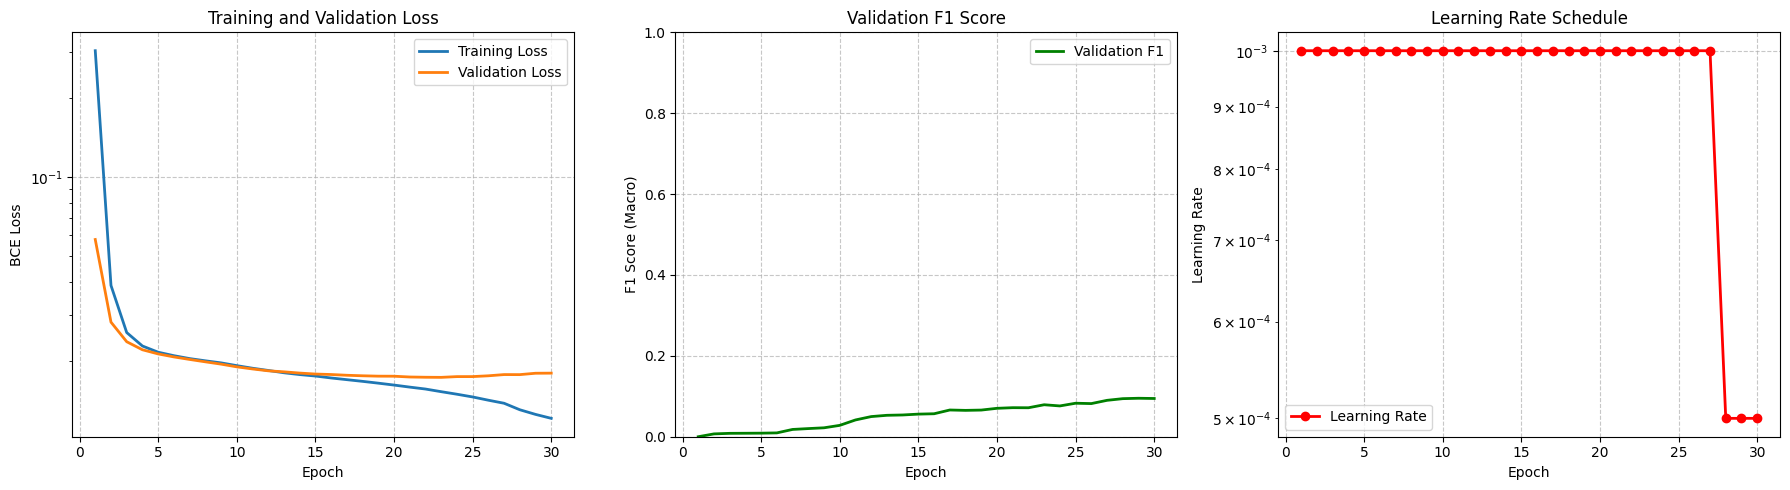

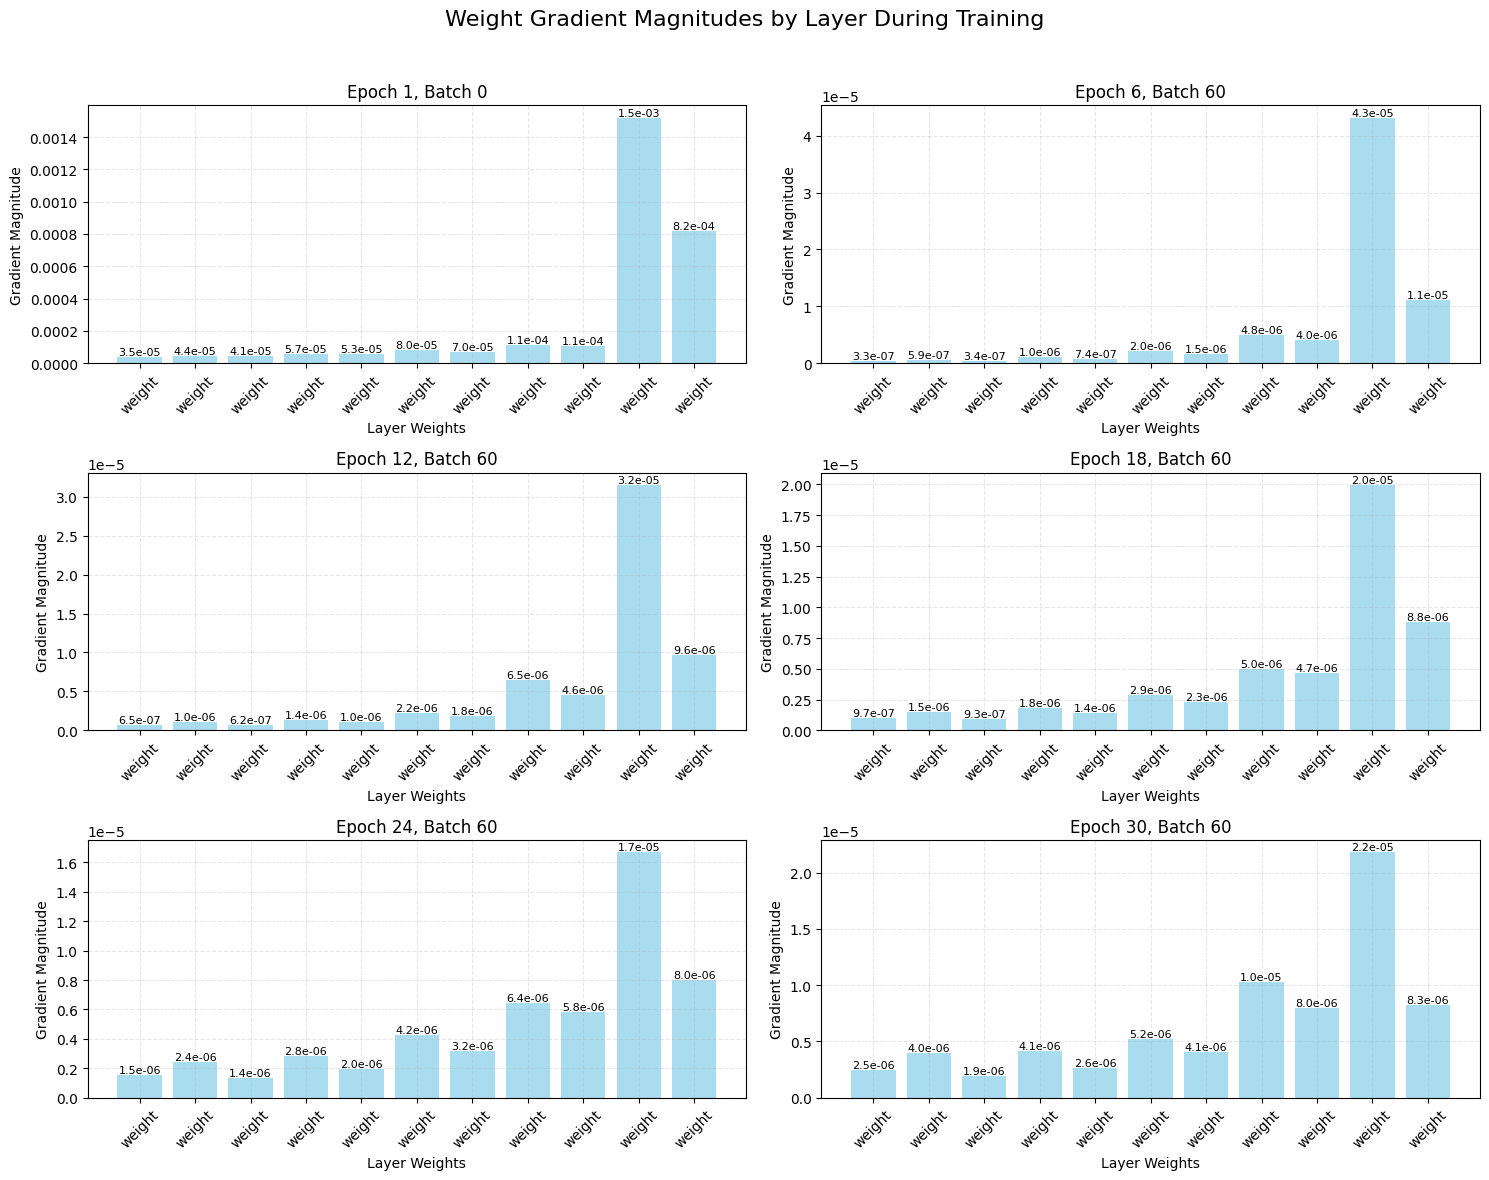

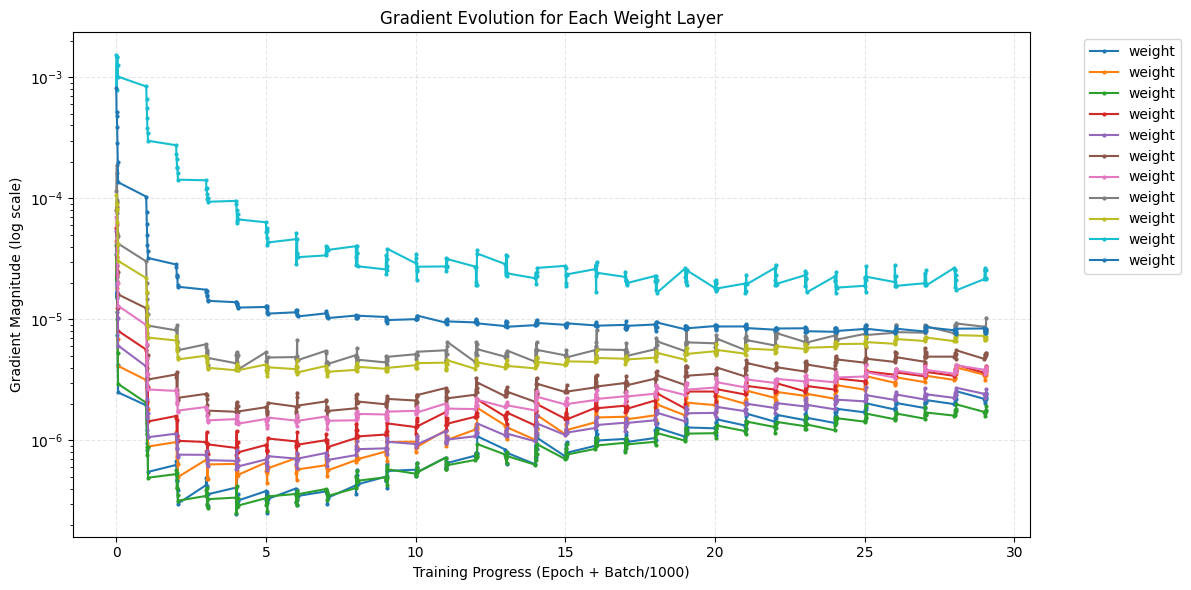

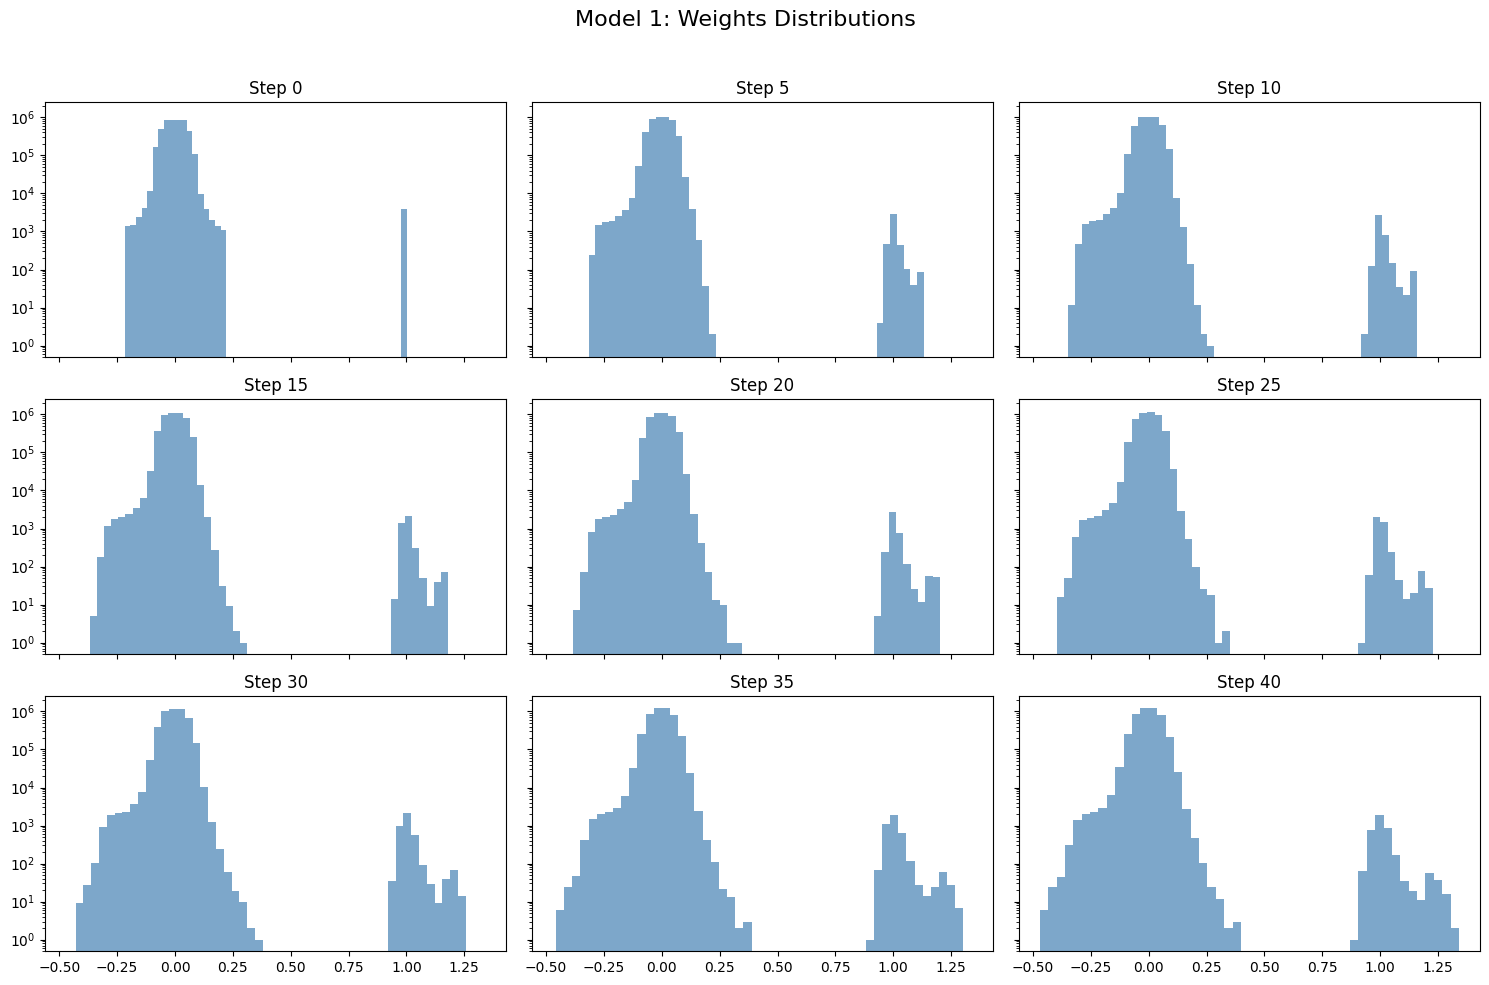

Submission saved as 'submission_model1.csv'


In [50]:
train_loss1, val_loss1, val_f11, predictions1, model1, submission_df1, grad_logs1, weight_logs1, learning_rates1 = train_moa_improved(
        init_type="he",
        batch_size=256,
        n_epoch=30,
        device=device,
        lr=1e-3,
        weight_decay=1e-5,
        log_grad_every=10,
        log_weights_every=50,
        use_dropout=True,
        dropout_rate=0.3,
        use_weight_decay=False,
        use_batch_norm=True,
        activation='relu',
        optimizer_type='adam',
        scheduler_type='plateau'
    )

plot_training_curves(train_loss1, val_loss1, val_f11, learning_rates1, "Model 1: Standard Configuration")
plot_weight_gradients_by_layer(grad_logs1)
plot_gradient_evolution(grad_logs1)
plot_weight_hist_grid(weight_logs1, title="Model 1: Weights Distributions")

trained_models.append(model1)
neural_net_predictions.append(predictions1)
neural_net_val_f1_scores.append(val_f11[-1])

submission_df1.to_csv('submission_model1.csv', index=False)
print("Submission saved as 'submission_model1.csv'")



## Model 2: Aggressive Regularization

    Optimizer: AdamW

    Scheduler: CosineAnnealing

    Regularization: Dropout (0.5) + Weight Decay (1e-4)

    Activation: ReLU

    Purpose: Test strong regularization

Categorical features shape: (21948, 5)
Numerical features shape: (21948, 872)
Combined features shape: (21948, 877)
Stratified split - Train: 17558, Val: 4390
Model Configuration:
  - Dropout: True (rate: 0.5)
  - Weight Decay: True (rate: 0.0001)
  - Batch Normalization: True
  - Activation: relu
  - Optimizer: adamw
  - Scheduler: cosine
  Learning rate changed from 1.00e-03 to 9.99e-04
Epoch [1/30], LR: 1.00e-03, Train Loss: 0.3097, Val Loss: 0.1163, Val F1: 0.0000
  Learning rate changed from 9.99e-04 to 9.96e-04
Epoch [2/30], LR: 9.99e-04, Train Loss: 0.0510, Val Loss: 0.0599, Val F1: 0.0037
  Learning rate changed from 9.96e-04 to 9.91e-04
Epoch [3/30], LR: 9.96e-04, Train Loss: 0.0304, Val Loss: 0.0413, Val F1: 0.0082
  Learning rate changed from 9.91e-04 to 9.84e-04
Epoch [4/30], LR: 9.91e-04, Train Loss: 0.0254, Val Loss: 0.0318, Val F1: 0.0093
  Learning rate changed from 9.84e-04 to 9.76e-04
Epoch [5/30], LR: 9.84e-04, Train Loss: 0.0232, Val Loss: 0.0271, Val F1: 0.0135
  L

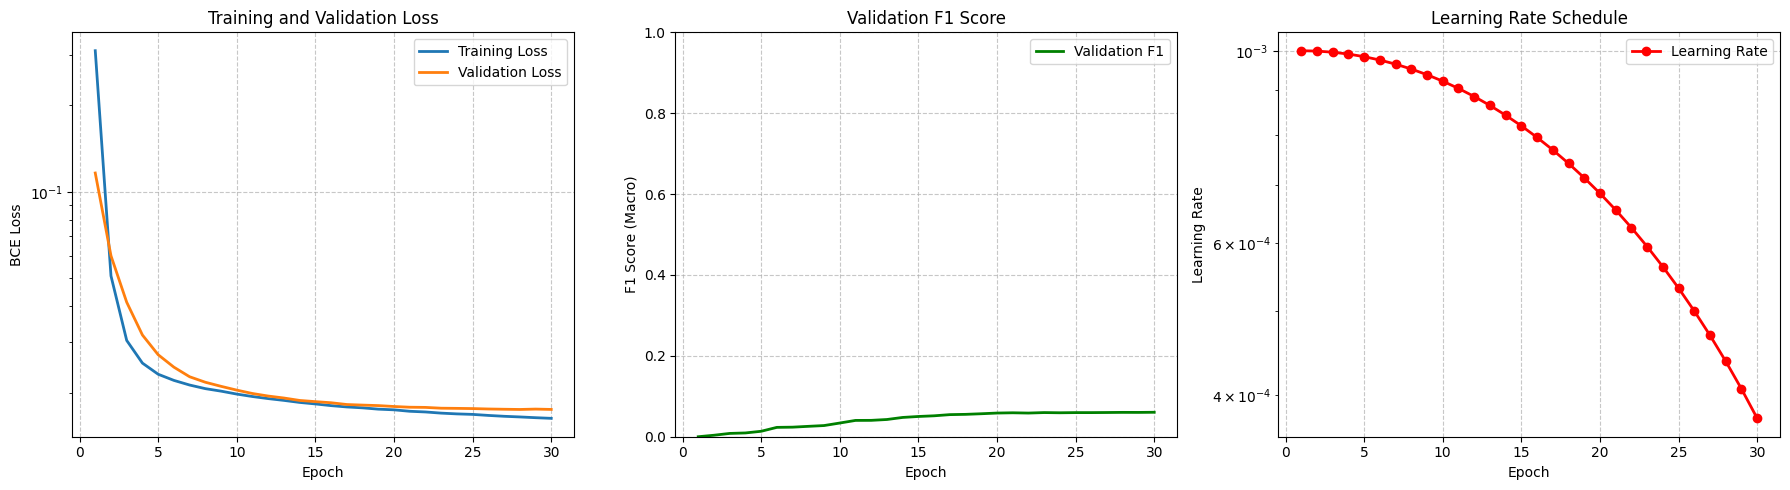

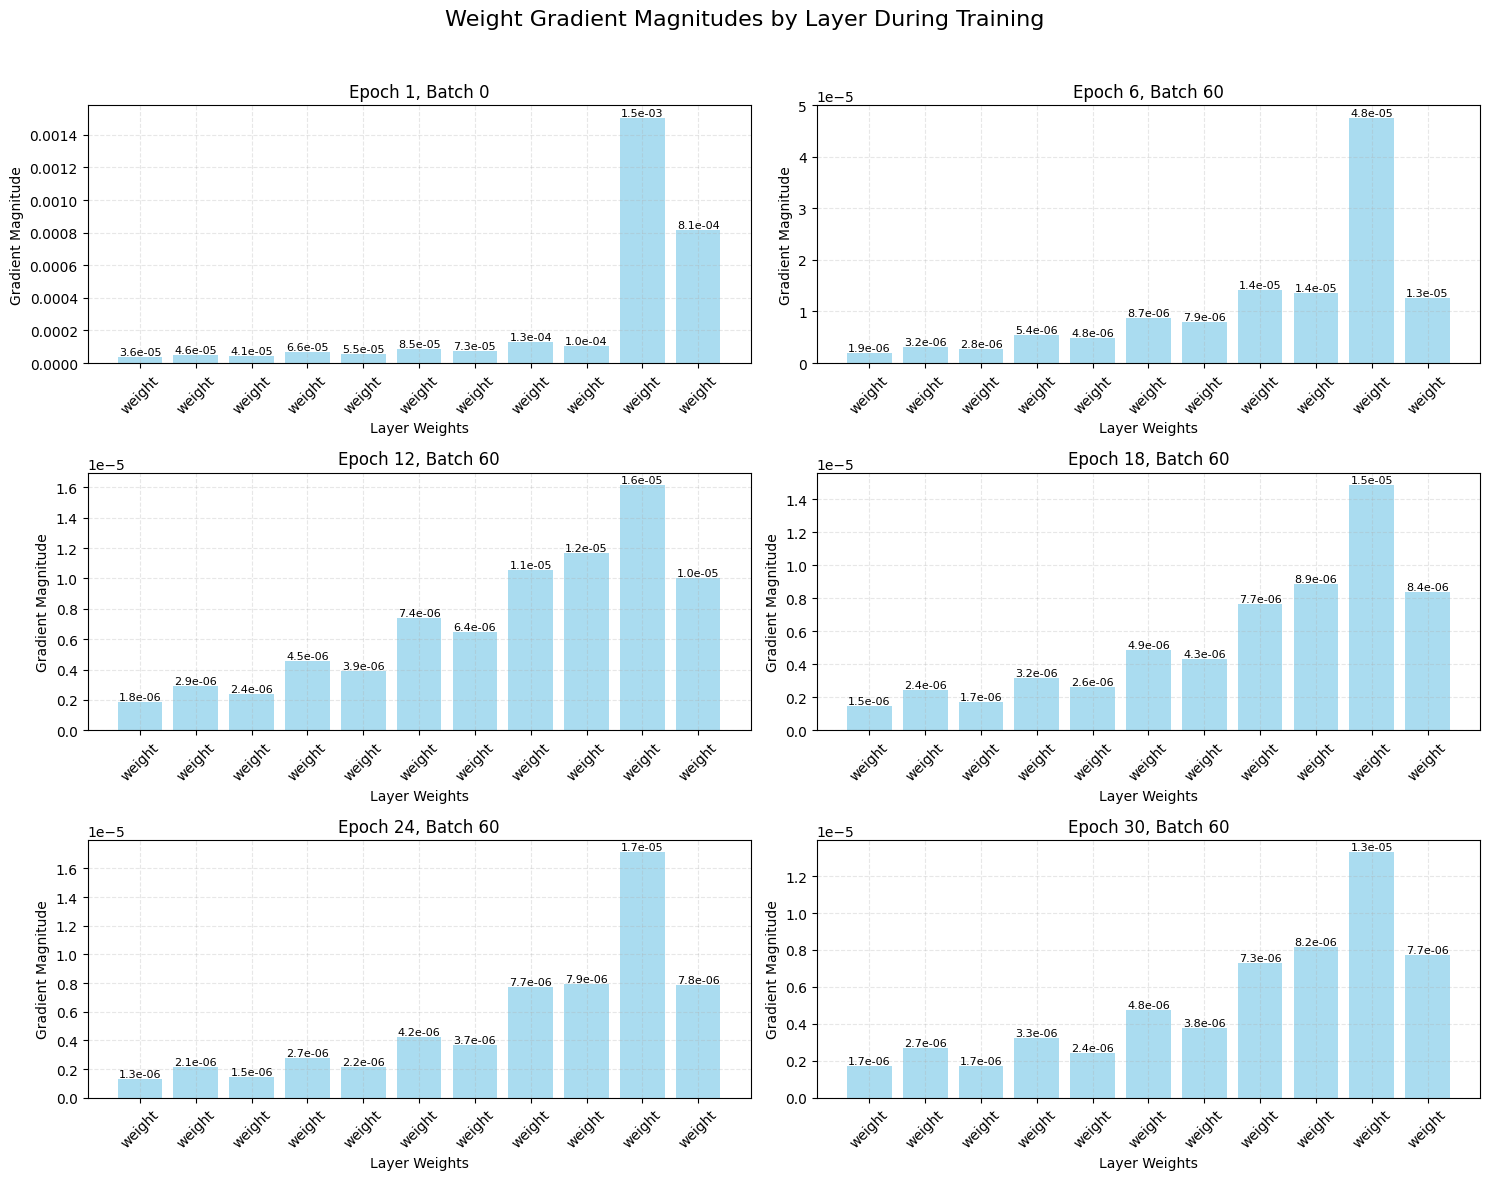

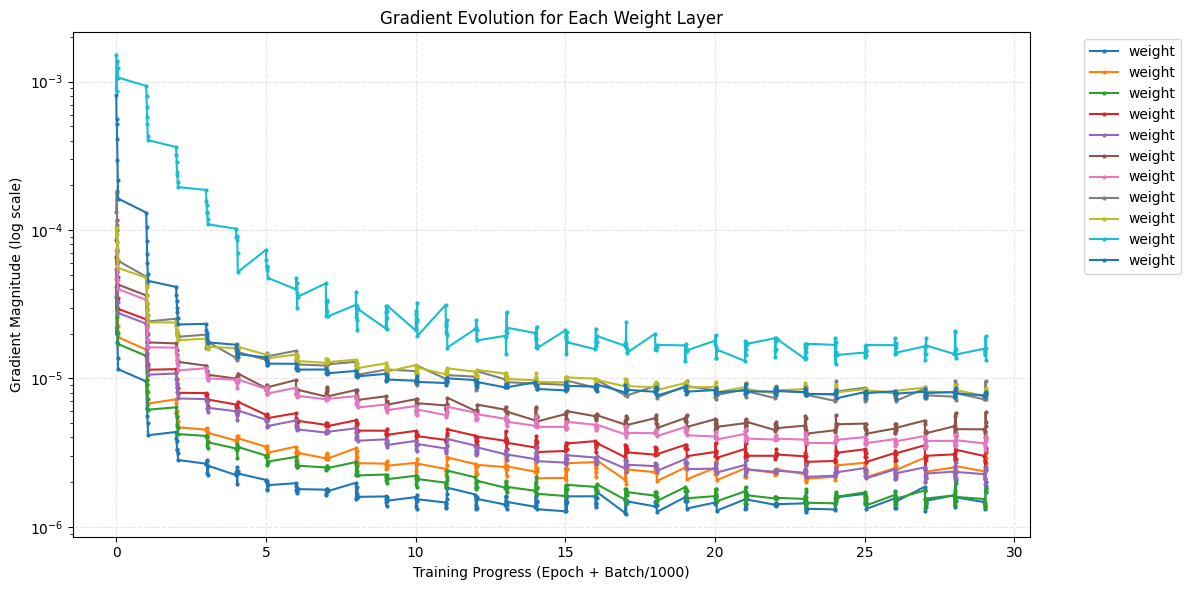

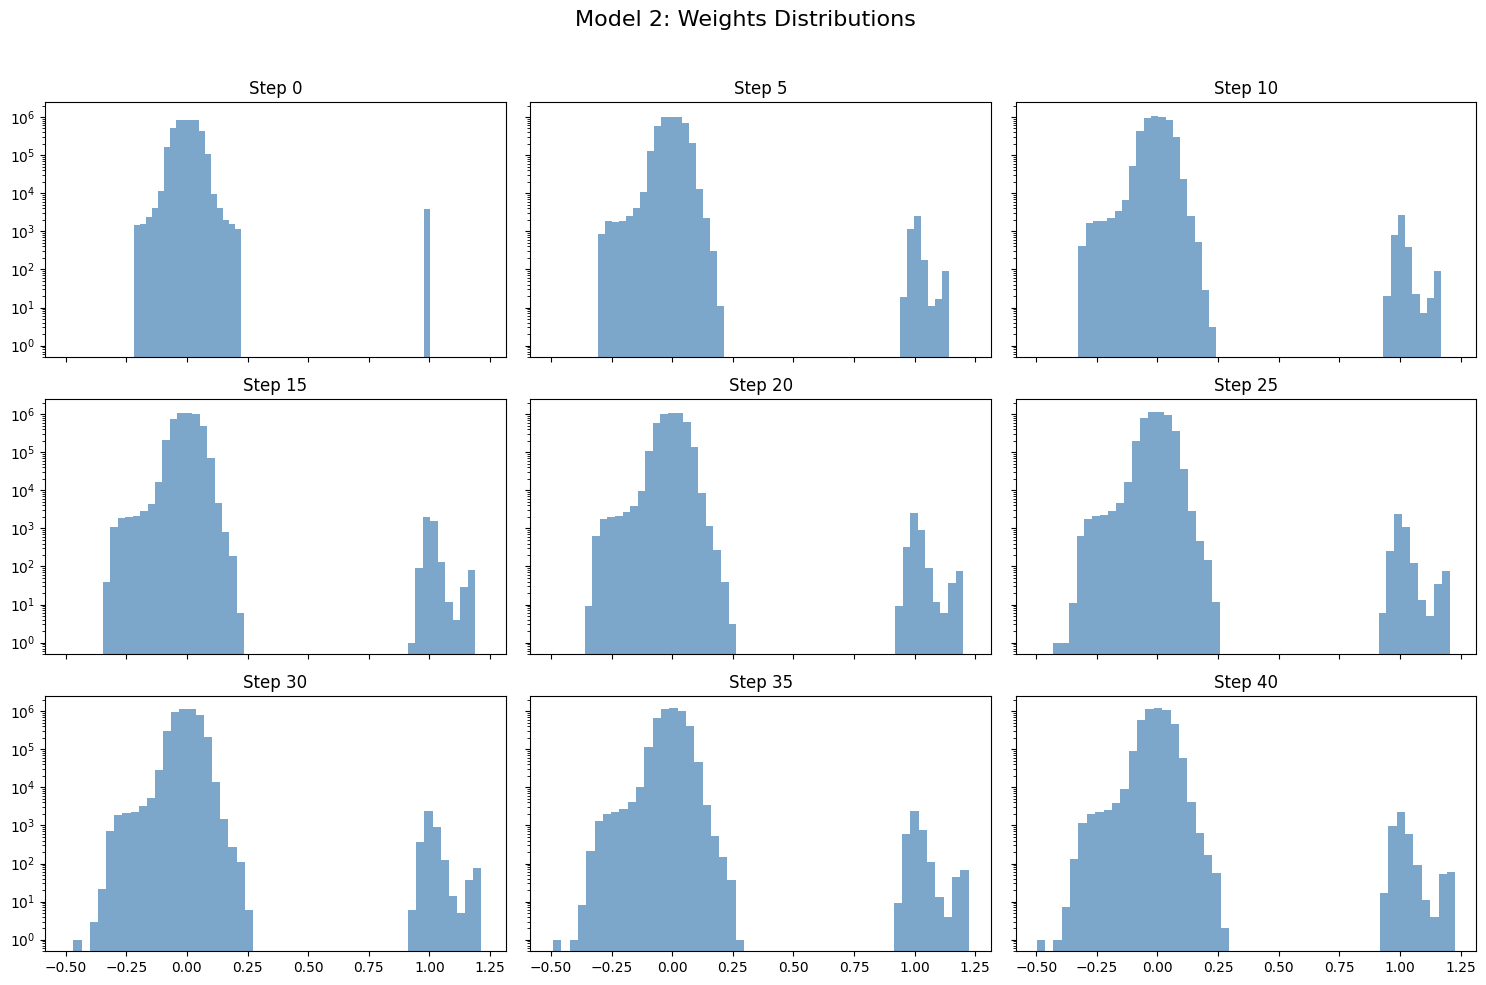

Submission saved as 'submission_model2.csv'


In [51]:
train_loss2, val_loss2, val_f12, predictions2, model2, submission_df2, grad_logs2, weight_logs2, learning_rates2 = train_moa_improved(
        init_type="he",
        batch_size=256,
        n_epoch=30,
        device=device,
        lr=1e-3,
        weight_decay=1e-4,
        log_grad_every=10,
        log_weights_every=50,
        use_dropout=True,
        dropout_rate=0.5,
        use_weight_decay=True,
        use_batch_norm=True,
        activation='relu',
        optimizer_type='adamw',
        scheduler_type='cosine'
    )




plot_training_curves(train_loss2, val_loss2, val_f12, learning_rates2, "Model 2: Aggressive Regularization")
plot_weight_gradients_by_layer(grad_logs2)
plot_gradient_evolution(grad_logs2)
plot_weight_hist_grid(weight_logs2, title="Model 2: Weights Distributions")

trained_models.append(model2)
neural_net_predictions.append(predictions2)
neural_net_val_f1_scores.append(val_f12[-1])

submission_df2.to_csv('submission_model2.csv', index=False)
print("Submission saved as 'submission_model2.csv'")


Model 3: Advanced Optimizer + Deeper Network

    Optimizer: Adam

    Scheduler: Exponential

    Regularization: Dropout (0.2)

    Activation: Leaky ReLU

    Batch Size: 128 (smaller)

    Purpose: Test different architecture choices

Categorical features shape: (21948, 5)
Numerical features shape: (21948, 872)
Combined features shape: (21948, 877)
Stratified split - Train: 17558, Val: 4390
Model Configuration:
  - Dropout: True (rate: 0.2)
  - Weight Decay: False (rate: 1e-05)
  - Batch Normalization: True
  - Activation: leaky_relu
  - Optimizer: adam
  - Scheduler: exponential
  Learning rate changed from 5.00e-04 to 4.75e-04
Epoch [1/40], LR: 5.00e-04, Train Loss: 0.2803, Val Loss: 0.0629, Val F1: 0.0000
  Learning rate changed from 4.75e-04 to 4.51e-04
Epoch [2/40], LR: 4.75e-04, Train Loss: 0.0429, Val Loss: 0.0312, Val F1: 0.0082
  Learning rate changed from 4.51e-04 to 4.29e-04
Epoch [3/40], LR: 4.51e-04, Train Loss: 0.0276, Val Loss: 0.0251, Val F1: 0.0089
  Learning rate changed from 4.29e-04 to 4.07e-04
Epoch [4/40], LR: 4.29e-04, Train Loss: 0.0238, Val Loss: 0.0228, Val F1: 0.0090
  Learning rate changed from 4.07e-04 to 3.87e-04
Epoch [5/40], LR: 4.07e-04, Train Loss: 0.0223, Val Loss: 0.0219, Val F1: 

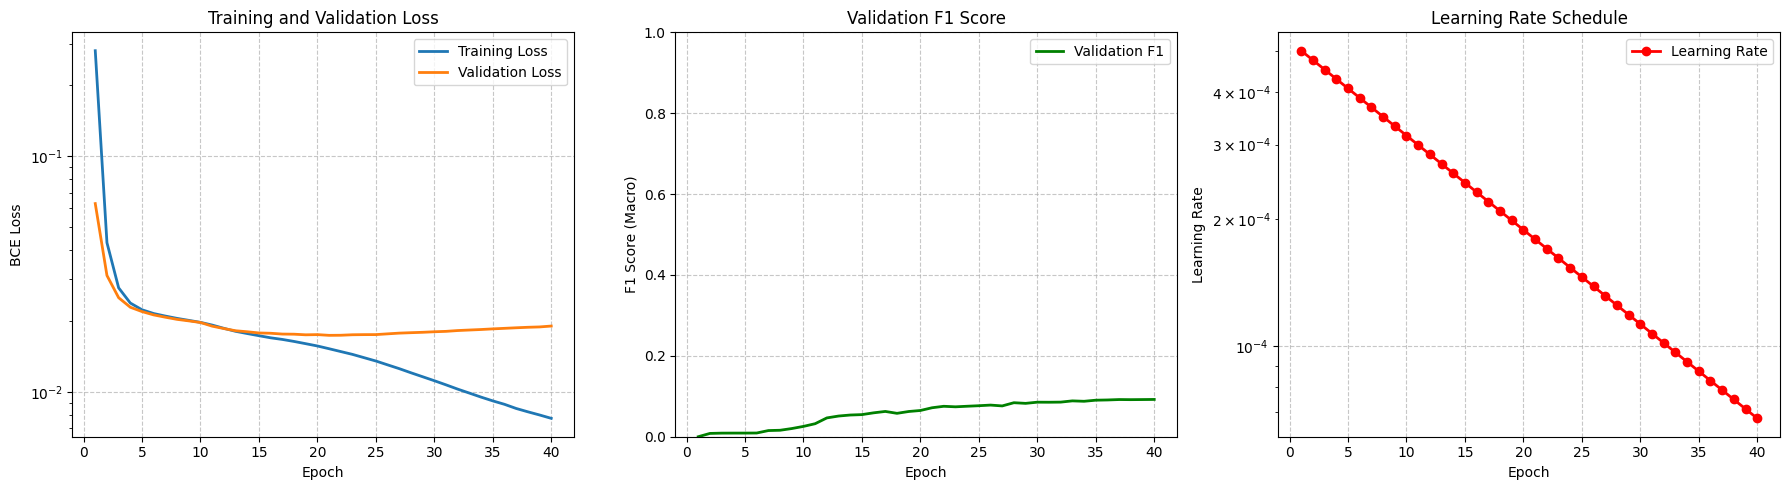

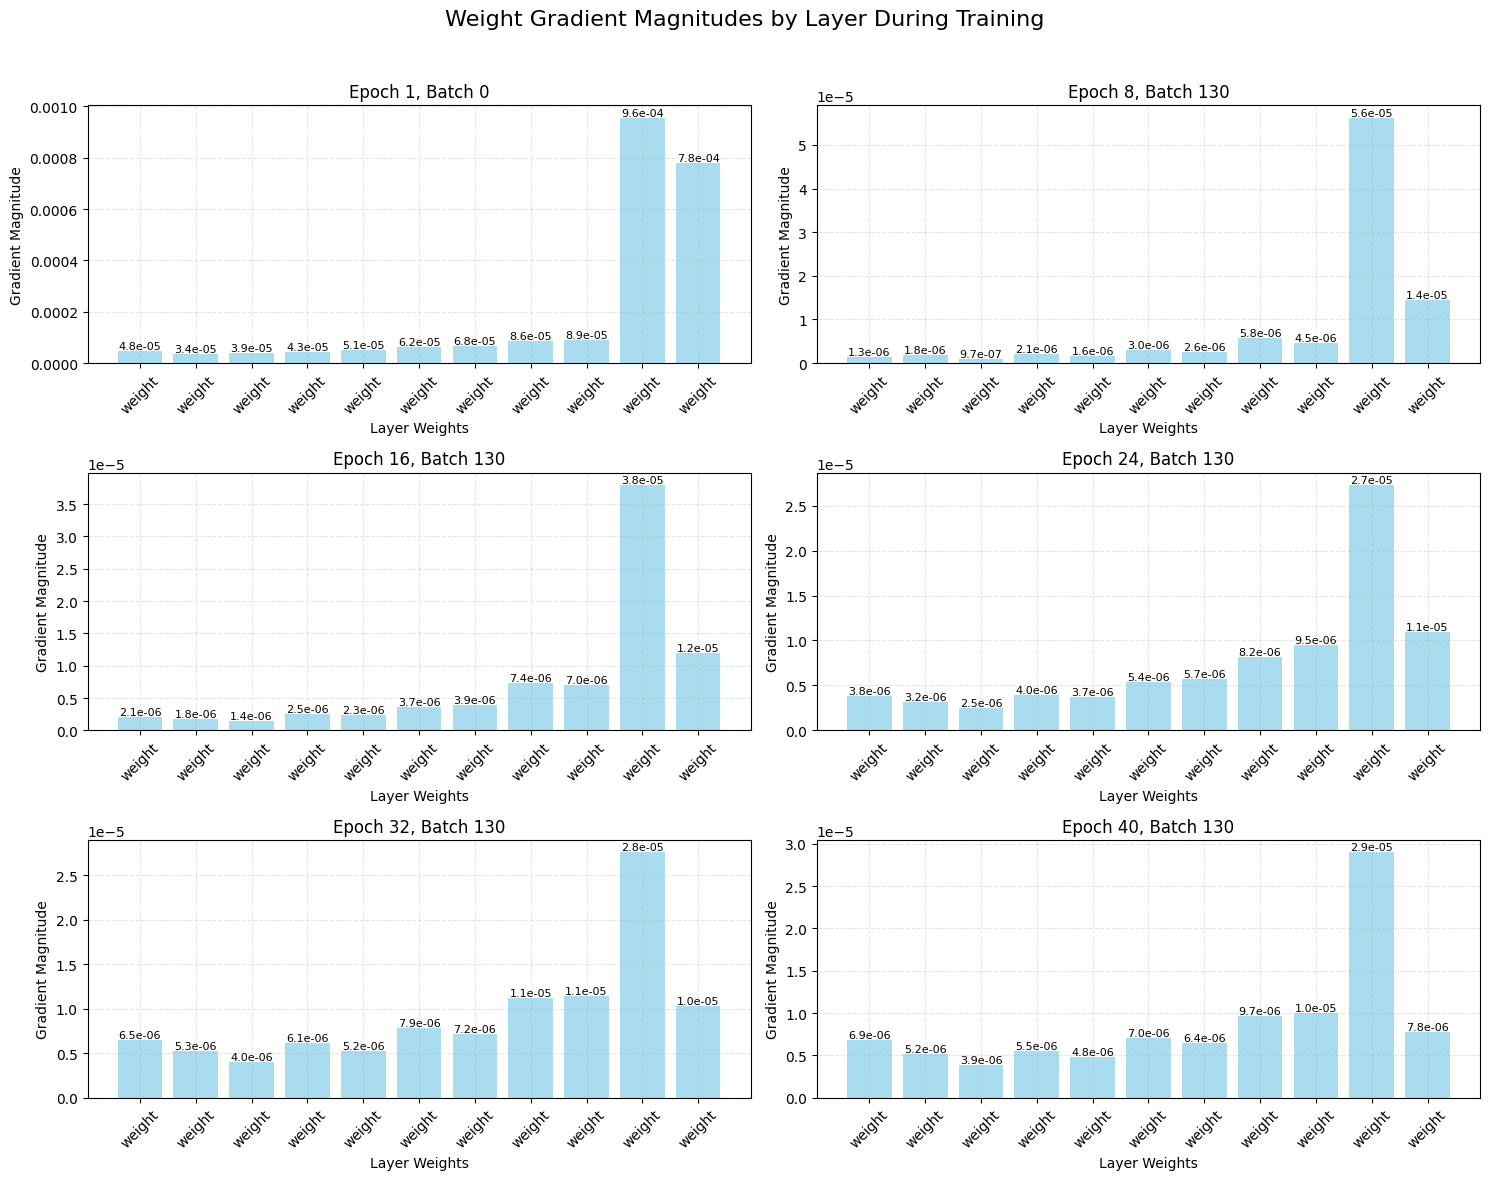

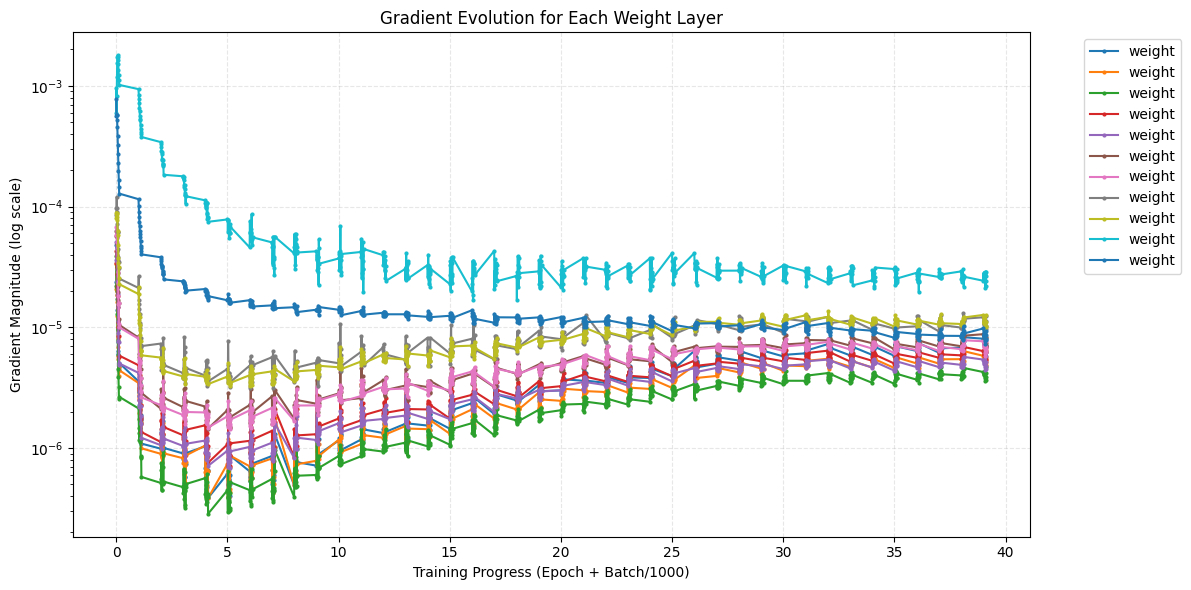

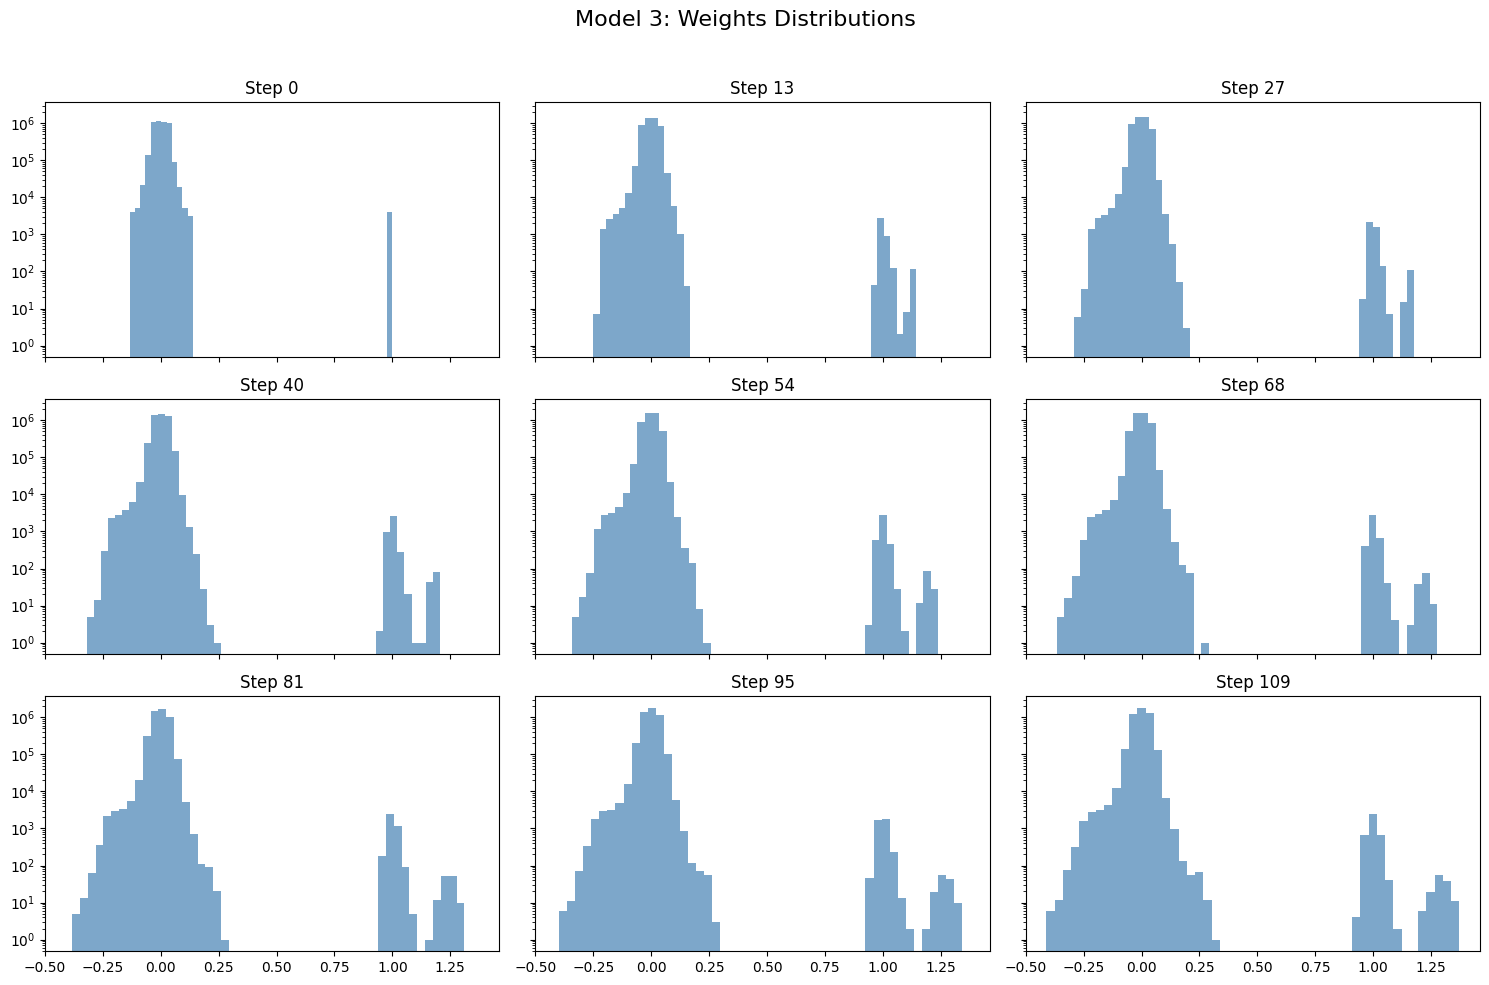

Submission saved as 'submission_model3.csv'


In [52]:


train_loss3, val_loss3, val_f13, predictions3, model3, submission_df3, grad_logs3, weight_logs3, learning_rates3 = train_moa_improved(
        init_type="xavier",
        batch_size=128,
        n_epoch=40,
        device=device,
        lr=5e-4,
        weight_decay=1e-5,
        log_grad_every=10,
        log_weights_every=50,
        use_dropout=True,
        dropout_rate=0.2,
        use_weight_decay=False,
        use_batch_norm=True,
        activation='leaky_relu',
        optimizer_type='adam',
        scheduler_type='exponential'
    )



plot_training_curves(train_loss3, val_loss3, val_f13, learning_rates3, "Model 3: Advanced Optimizer")
plot_weight_gradients_by_layer(grad_logs3)
plot_gradient_evolution(grad_logs3)
plot_weight_hist_grid(weight_logs3, title="Model 3: Weights Distributions")

trained_models.append(model3)
neural_net_predictions.append(predictions3)
neural_net_val_f1_scores.append(val_f13[-1])

submission_df3.to_csv('submission_model3.csv', index=False)
print("Submission saved as 'submission_model3.csv'")



## Model 4: SGD with Momentum (Classic)

    Optimizer: SGD with momentum

    Scheduler: StepLR

    Regularization: Dropout (0.4) + Weight Decay (1e-4)

    Activation: ReLU

    Learning Rate: Higher (1e-2)

    Purpose: Test classic optimization approach

Categorical features shape: (21948, 5)
Numerical features shape: (21948, 872)
Combined features shape: (21948, 877)
Stratified split - Train: 17558, Val: 4390
Model Configuration:
  - Dropout: True (rate: 0.4)
  - Weight Decay: True (rate: 0.0001)
  - Batch Normalization: True
  - Activation: relu
  - Optimizer: sgd
  - Scheduler: step
Epoch [1/35], LR: 1.00e-02, Train Loss: 0.7265, Val Loss: 0.6560, Val F1: 0.0104
Epoch [2/35], LR: 1.00e-02, Train Loss: 0.6105, Val Loss: 0.5929, Val F1: 0.0116
Epoch [3/35], LR: 1.00e-02, Train Loss: 0.5132, Val Loss: 0.5246, Val F1: 0.0103
Epoch [4/35], LR: 1.00e-02, Train Loss: 0.4280, Val Loss: 0.4501, Val F1: 0.0070
Epoch [5/35], LR: 1.00e-02, Train Loss: 0.3554, Val Loss: 0.3814, Val F1: 0.0037
Epoch [6/35], LR: 1.00e-02, Train Loss: 0.2960, Val Loss: 0.3198, Val F1: 0.0026
Epoch [7/35], LR: 1.00e-02, Train Loss: 0.2485, Val Loss: 0.2710, Val F1: 0.0019
Epoch [8/35], LR: 1.00e-02, Train Loss: 0.2107, Val Loss: 0.2280, Val F1: 0.0007
Epoch [9/35], 

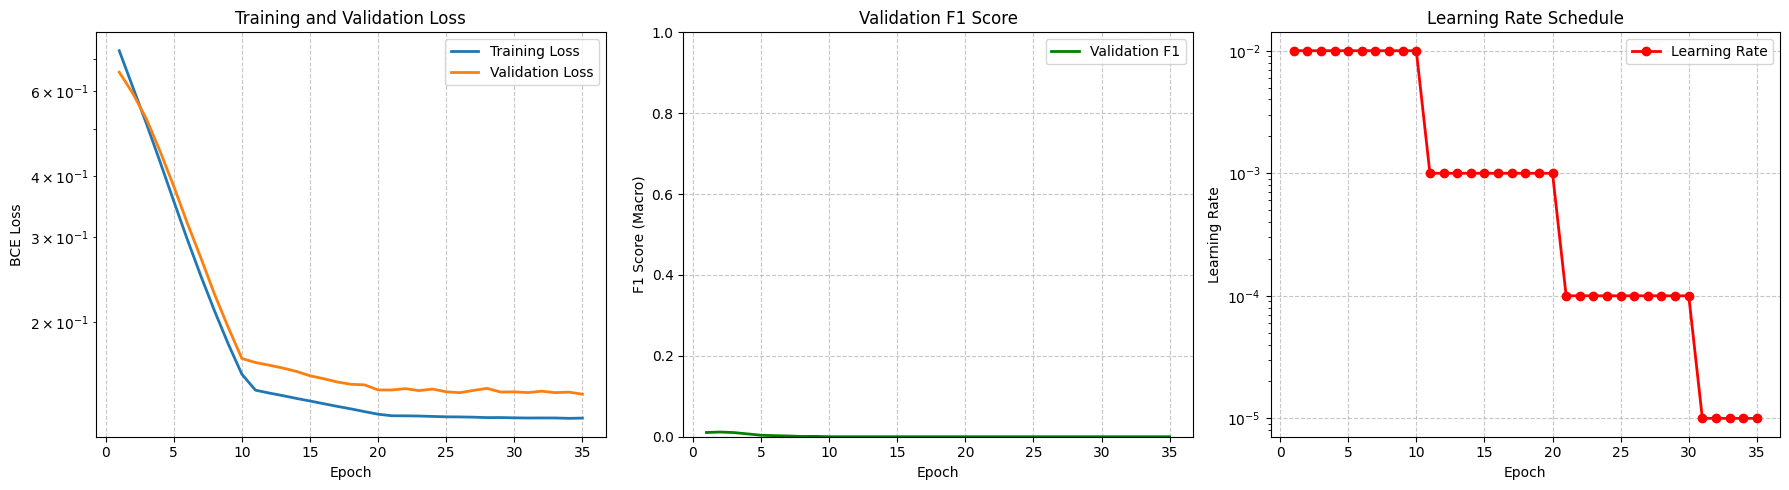

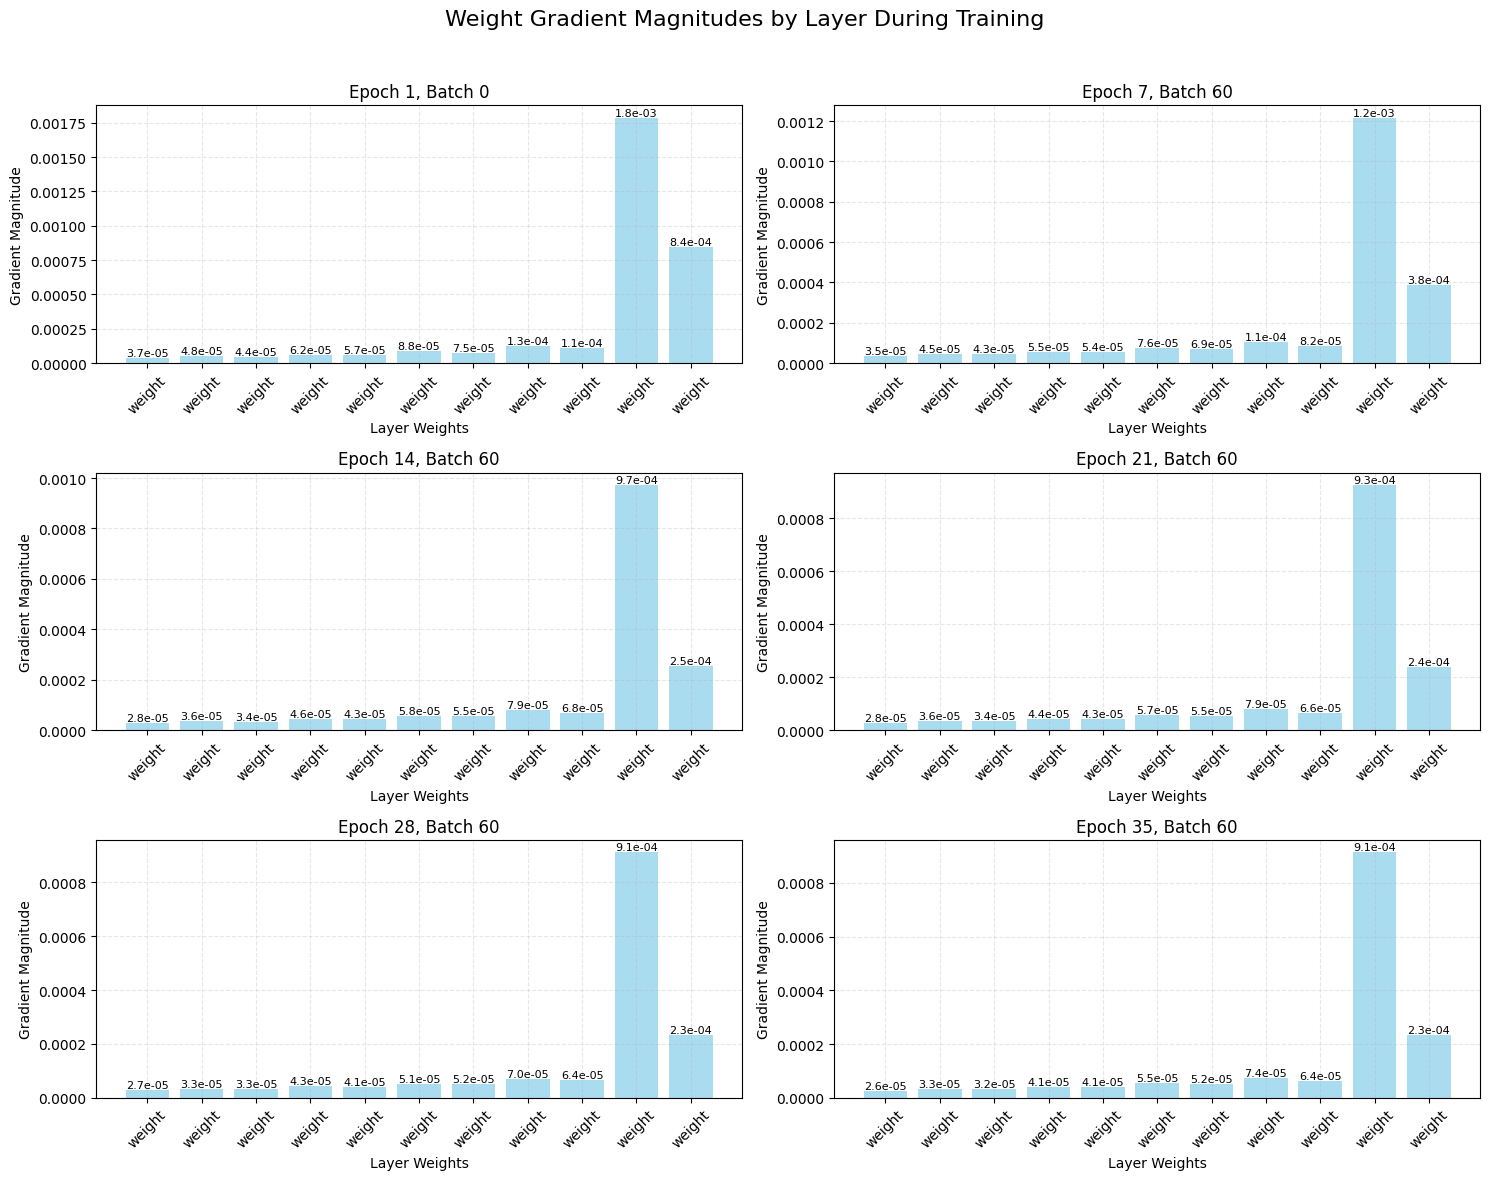

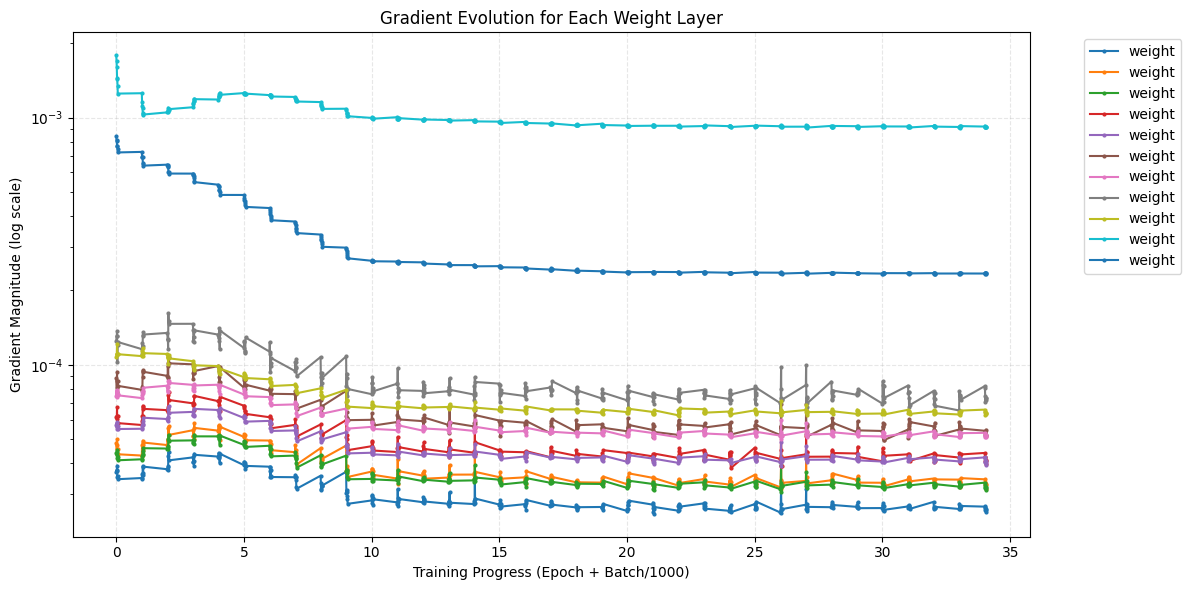

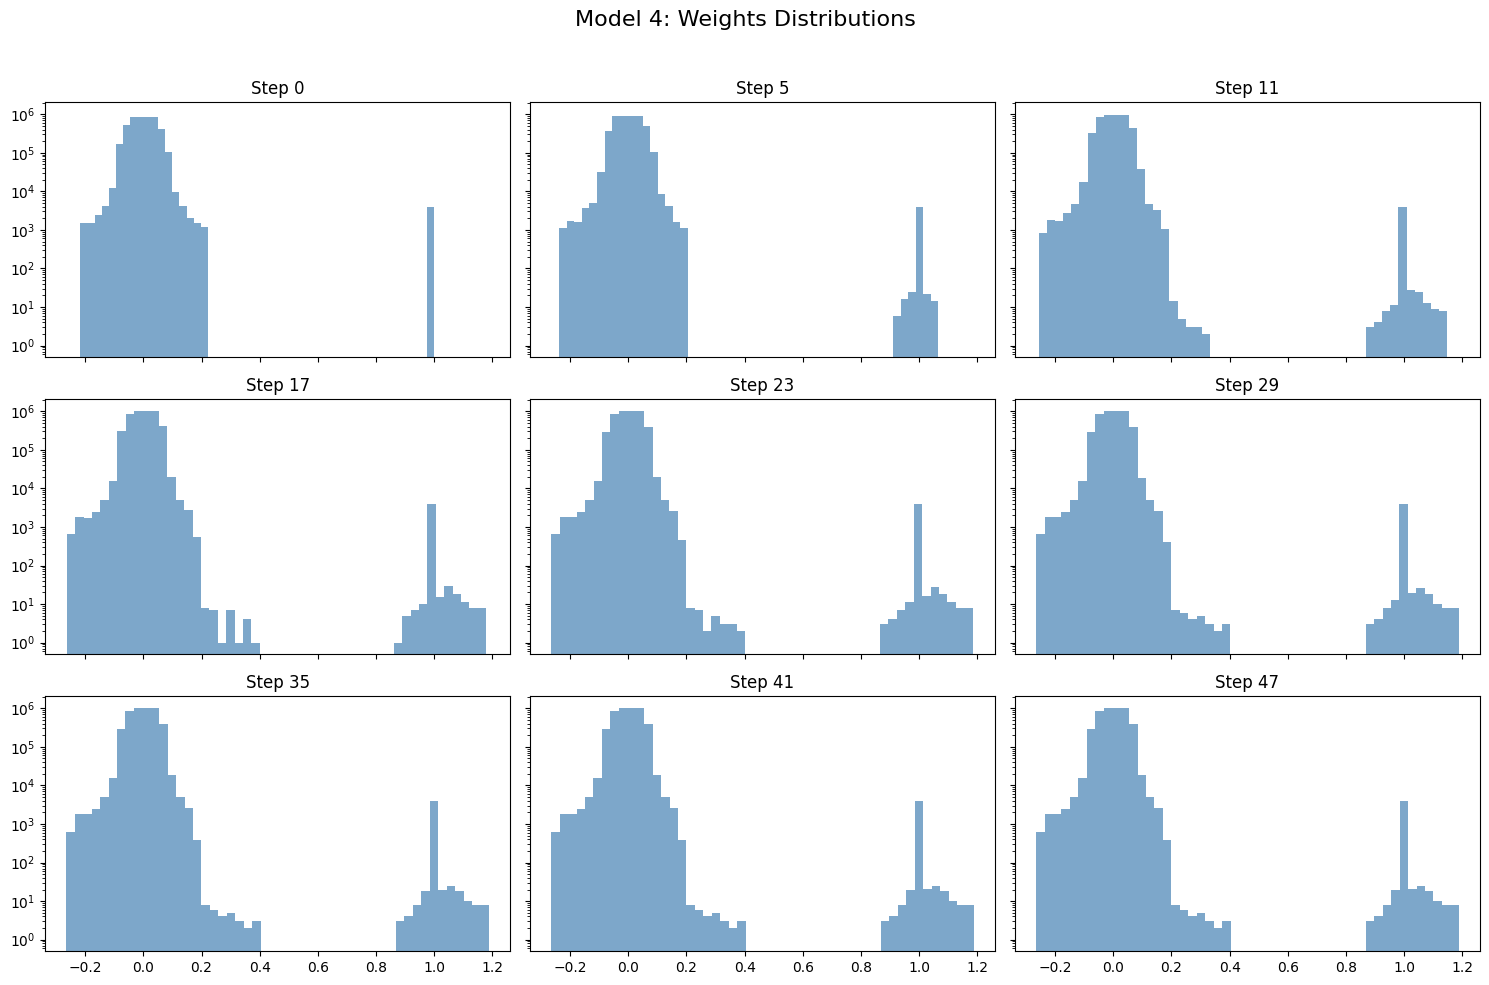

Submission saved as 'submission_model4.csv'


In [53]:
train_loss4, val_loss4, val_f14, predictions4, model4, submission_df4, grad_logs4, weight_logs4, learning_rates4 = train_moa_improved(
        init_type="he",
        batch_size=256,
        n_epoch=35,
        device=device,
        lr=1e-2,
        weight_decay=1e-4,
        log_grad_every=10,
        log_weights_every=50,
        use_dropout=True,
        dropout_rate=0.4,
        use_weight_decay=True,
        use_batch_norm=True,
        activation='relu',
        optimizer_type='sgd',
        scheduler_type='step'
    )


plot_training_curves(train_loss4, val_loss4, val_f14, learning_rates4, "Model 4: SGD with Momentum")
plot_weight_gradients_by_layer(grad_logs4)
plot_gradient_evolution(grad_logs4)
plot_weight_hist_grid(weight_logs4, title="Model 4: Weights Distributions")

trained_models.append(model4)
neural_net_predictions.append(predictions4)
neural_net_val_f1_scores.append(val_f14[-1])

submission_df4.to_csv('submission_model4.csv', index=False)
print("Submission saved as 'submission_model4.csv'")




 # Simple comparison

In [54]:
print("\n" + "="*60)
print("FINAL VALIDATION RESULTS")

print(f"Model 1 - Val Loss: {val_loss1[-1]:.4f}, Val F1: {val_f11[-1]:.4f}")
print(f"Model 2 - Val Loss: {val_loss2[-1]:.4f}, Val F1: {val_f12[-1]:.4f}")
print(f"Model 3 - Val Loss: {val_loss3[-1]:.4f}, Val F1: {val_f13[-1]:.4f}")
print(f"Model 4 - Val Loss: {val_loss4[-1]:.4f}, Val F1: {val_f14[-1]:.4f}")



FINAL VALIDATION RESULTS
Model 1 - Val Loss: 0.0180, Val F1: 0.0945
Model 2 - Val Loss: 0.0175, Val F1: 0.0605
Model 3 - Val Loss: 0.0190, Val F1: 0.0922
Model 4 - Val Loss: 0.1419, Val F1: 0.0000


# Ensembling

## Prediction from Neural network

In [55]:
def get_neural_net_val_predictions_optimized(trained_model, X_train, y_train, X_val, target_idx):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    X_val_tensor = torch.FloatTensor(X_val).to(device)

    trained_model.eval()
    with torch.no_grad():
        val_outputs = trained_model(X_val_tensor)

        if val_outputs.shape[1] > 1:
            val_pred = torch.sigmoid(val_outputs[:, target_idx]).cpu().numpy()
        else:
            val_pred = torch.sigmoid(val_outputs).cpu().numpy().flatten()

    return val_pred

## Strategy 1: Diverse Meta-Learners

    Train all 5 meta-learner types separately

    Creates 20 ensembles (5 meta-learners × 4 neural networks)

    Each gives a different "opinion" on how to combine predictions


In [60]:
def strategy1_diverse_meta_learners_optimized(X_train, y_train, X_test, trained_models,
                                            neural_net_predictions, test_sig_id, target_names):
    print("\n" + "="*60)
    print("STRATEGY 1: DIVERSE META-LEARNERS")
    print("="*60)

    X_train_stack, X_val_stack, y_train_stack, y_val_stack = create_stratified_split(
        X_train, y_train, validation_split=0.3
    )

    meta_learners = {
        'logistic_regression': LogisticRegression(random_state=42, max_iter=1000, C=1.0),
        'random_forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
        'svm': SVC(probability=True, random_state=42, kernel='linear', C=1.0),
        'lightgbm': lgb.LGBMClassifier(n_estimators=100, random_state=42, max_depth=3, learning_rate=0.1),
        'mlp': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=500, alpha=0.01)
    }

    all_stacked_submissions = {}

    for i, (trained_model, nn_pred) in enumerate(zip(trained_models, neural_net_predictions)):
        print(f"\nProcessing Neural Network {i+1}")

        for meta_name, meta_learner in meta_learners.items():
            print(f"  Training {meta_name} meta-learner...")

            stacked_predictions = []
            failed_targets = 0

            for target_idx in tqdm(range(y_train.shape[1]), desc=f"Targets for {meta_name}"):
                try:
                    unique_classes = np.unique(y_train_stack[:, target_idx])
                    if len(unique_classes) < 2:
                        stacked_predictions.append(nn_pred[:, target_idx])
                        failed_targets += 1
                        continue

                    nn_val_pred = get_neural_net_val_predictions_optimized(
                        trained_model, X_train_stack, y_train_stack[:, target_idx], X_val_stack, target_idx
                    )

                    xgb_base = xgb.XGBClassifier(
                        n_estimators=50,
                        max_depth=3,
                        learning_rate=0.1,
                        random_state=42,
                        base_score=0.5
                    )

                    xgb_base.fit(X_train_stack, y_train_stack[:, target_idx])
                    xgb_val_pred = xgb_base.predict_proba(X_val_stack)[:, 1]

                    meta_features_val = np.column_stack([nn_val_pred, xgb_val_pred])

                    meta_learner.fit(meta_features_val, y_val_stack[:, target_idx])

                    nn_test_pred = nn_pred[:, target_idx]
                    xgb_test_pred = xgb_base.predict_proba(X_test)[:, 1]
                    meta_features_test = np.column_stack([nn_test_pred, xgb_test_pred])

                    if hasattr(meta_learner, 'predict_proba'):
                        final_pred = meta_learner.predict_proba(meta_features_test)[:, 1]
                    else:
                        final_pred = meta_learner.predict(meta_features_test)

                    stacked_predictions.append(final_pred)

                except Exception as e:
                    failed_targets += 1

                    try:
                        xgb_fallback = xgb.XGBClassifier(
                            n_estimators=20,
                            max_depth=2,
                            learning_rate=0.1,
                            random_state=42,
                            base_score=0.5
                        )
                        xgb_fallback.fit(X_train_stack, y_train_stack[:, target_idx])
                        xgb_test_pred = xgb_fallback.predict_proba(X_test)[:, 1]
                        final_pred = (nn_pred[:, target_idx] * 0.7 + xgb_test_pred * 0.3)
                    except Exception as e2:
                        final_pred = nn_pred[:, target_idx]

                    stacked_predictions.append(final_pred)

            stacked_predictions = np.column_stack(stacked_predictions)
            submission = pd.DataFrame({
                'sig_id': test_sig_id,
                **{target: stacked_predictions[:, j] for j, target in enumerate(target_names)}
            })

            key = f"strategy1_nn{i+1}_{meta_name}"
            all_stacked_submissions[key] = submission
            print(f"    {key} completed - {failed_targets}/{y_train.shape[1]} targets used fallback")

    return all_stacked_submissions



## Strategy 2: Meta-Learner Ensemble

    Combine multiple meta-learners (Logistic Regression + Random Forest + LightGBM)

    Average their predictions for extra robustness

    Creates 4 ensembles (one per neural network)

In [61]:
def strategy2_meta_learner_ensemble_optimized(X_train, y_train, X_test, trained_models,
                                            neural_net_predictions, test_sig_id, target_names):
    print("\n" + "="*60)
    print("STRATEGY 2: META-LEARNER ENSEMBLE")
    print("="*60)

    X_train_stack, X_val_stack, y_train_stack, y_val_stack = create_stratified_split(
        X_train, y_train, validation_split=0.3
    )

    meta_learners = {
        'logistic_regression': LogisticRegression(random_state=42, max_iter=1000),
        'random_forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
        'lightgbm': lgb.LGBMClassifier(n_estimators=100, random_state=42, max_depth=3)
    }

    ensemble_submissions = []

    for i, (trained_model, nn_pred) in enumerate(zip(trained_models, neural_net_predictions)):
        print(f"\nCreating Meta-Ensemble for Neural Network {i+1}")

        ensemble_predictions = []

        for target_idx in tqdm(range(y_train.shape[1]), desc=f"Meta-Ensemble {i+1}"):
            try:
                unique_classes = np.unique(y_train_stack[:, target_idx])
                if len(unique_classes) < 2:
                    ensemble_predictions.append(nn_pred[:, target_idx])
                    continue

                nn_val_pred = get_neural_net_val_predictions_optimized(
                    trained_model, X_train_stack, y_train_stack[:, target_idx], X_val_stack, target_idx
                )

                xgb_base = xgb.XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42, base_score=0.5)
                xgb_base.fit(X_train_stack, y_train_stack[:, target_idx])
                xgb_val_pred = xgb_base.predict_proba(X_val_stack)[:, 1]

                meta_features_val = np.column_stack([nn_val_pred, xgb_val_pred])

                meta_predictions_test = []

                for meta_name, meta_learner in meta_learners.items():
                    try:
                        meta_learner.fit(meta_features_val, y_val_stack[:, target_idx])

                        nn_test_pred = nn_pred[:, target_idx]
                        xgb_test_pred = xgb_base.predict_proba(X_test)[:, 1]
                        meta_features_test = np.column_stack([nn_test_pred, xgb_test_pred])

                        if hasattr(meta_learner, 'predict_proba'):
                            pred = meta_learner.predict_proba(meta_features_test)[:, 1]
                        else:
                            pred = meta_learner.predict(meta_features_test)

                        meta_predictions_test.append(pred)
                    except Exception:
                        continue

                if len(meta_predictions_test) > 0:
                    final_pred = np.mean(meta_predictions_test, axis=0)
                else:
                    final_pred = (nn_pred[:, target_idx] + xgb_base.predict_proba(X_test)[:, 1]) / 2

                ensemble_predictions.append(final_pred)

            except Exception:
                ensemble_predictions.append(nn_pred[:, target_idx])

        ensemble_predictions = np.column_stack(ensemble_predictions)
        submission = pd.DataFrame({
            'sig_id': test_sig_id,
            **{target: ensemble_predictions[:, j] for j, target in enumerate(target_names)}
        })

        ensemble_submissions.append(submission)

    return ensemble_submissions



## Strategy 3: Weighted Stacking

    Select the best meta-learner per target based on validation performance

    Different targets might need different combination strategies

    Adaptive approach - optimal for each specific MoA mechanism

    Creates 4 ensembles (one per neural network)

In [63]:
def strategy3_weighted_stacking_optimized(X_train, y_train, X_test, trained_models,
                                        neural_net_predictions, neural_net_val_f1_scores,
                                        test_sig_id, target_names):
    print("\n" + "="*60)
    print("STRATEGY 3: WEIGHTED STACKING")
    print("="*60)

    X_train_stack, X_val_stack, y_train_stack, y_val_stack = create_stratified_split(
        X_train, y_train, validation_split=0.3
    )

    meta_learners = {
        'logistic_regression': LogisticRegression(random_state=42, max_iter=1000),
        'random_forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
        'lightgbm': lgb.LGBMClassifier(n_estimators=100, random_state=42, max_depth=3)
    }

    weighted_submissions = []

    for i, (trained_model, nn_pred, nn_f1) in enumerate(zip(trained_models, neural_net_predictions, neural_net_val_f1_scores)):
        print(f"\nCreating Weighted Stacking for Neural Network {i+1}")

        weighted_predictions = []
        meta_learner_selections = []

        for target_idx in tqdm(range(y_train.shape[1]), desc=f"Weighted Stacking {i+1}"):
            try:
                unique_classes = np.unique(y_train_stack[:, target_idx])
                if len(unique_classes) < 2:
                    weighted_predictions.append(nn_pred[:, target_idx])
                    meta_learner_selections.append("single_class")
                    continue

                nn_val_pred = get_neural_net_val_predictions_optimized(
                    trained_model, X_train_stack, y_train_stack[:, target_idx], X_val_stack, target_idx
                )

                xgb_base = xgb.XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42, base_score=0.5)
                xgb_base.fit(X_train_stack, y_train_stack[:, target_idx])
                xgb_val_pred = xgb_base.predict_proba(X_val_stack)[:, 1]

                meta_features_val = np.column_stack([nn_val_pred, xgb_val_pred])

                best_score = -1
                best_learner = None
                best_learner_name = "average"

                for meta_name, meta_learner in meta_learners.items():
                    try:
                        meta_learner.fit(meta_features_val, y_val_stack[:, target_idx])

                        if hasattr(meta_learner, 'predict_proba'):
                            val_pred = meta_learner.predict_proba(meta_features_val)[:, 1]
                        else:
                            val_pred = meta_learner.predict(meta_features_val)

                        val_pred_binary = (val_pred > 0.5).astype(int)
                        score = accuracy_score(y_val_stack[:, target_idx], val_pred_binary)

                        if score > best_score:
                            best_score = score
                            best_learner = meta_learner
                            best_learner_name = meta_name
                    except Exception:
                        continue

                nn_test_pred = nn_pred[:, target_idx]
                xgb_test_pred = xgb_base.predict_proba(X_test)[:, 1]
                meta_features_test = np.column_stack([nn_test_pred, xgb_test_pred])

                if best_learner is not None:
                    if hasattr(best_learner, 'predict_proba'):
                        final_pred = best_learner.predict_proba(meta_features_test)[:, 1]
                    else:
                        final_pred = best_learner.predict(meta_features_test)
                else:
                    final_pred = (nn_test_pred * 0.7 + xgb_test_pred * 0.3)

                weighted_predictions.append(final_pred)
                meta_learner_selections.append(best_learner_name)

            except Exception:
                weighted_predictions.append(nn_pred[:, target_idx])
                meta_learner_selections.append("error")

        weighted_predictions = np.column_stack(weighted_predictions)
        submission = pd.DataFrame({
            'sig_id': test_sig_id,
            **{target: weighted_predictions[:, j] for j, target in enumerate(target_names)}
        })

        weighted_submissions.append(submission)

        unique, counts = np.unique(meta_learner_selections, return_counts=True)
        print(f"Meta-learner selections for NN {i+1}:")
        for meta_name, count in zip(unique, counts):
            print(f"  {meta_name}: {count} targets")

    return weighted_submissions

In [ ]:
# Strategy 1: Diverse Meta-Learners
strategy1_results = strategy1_diverse_meta_learners_optimized(
    X_train_split, y_train_split, X_test, trained_models,
    neural_net_predictions, test_sig_id, target_names
)

# Strategy 2: Meta-Learner Ensemble
strategy2_results = strategy2_meta_learner_ensemble_optimized(
    X_train_split, y_train_split, X_test, trained_models,
    neural_net_predictions, test_sig_id, target_names
)

# Strategy 3: Weighted Stacking
strategy3_results = strategy3_weighted_stacking_optimized(
    X_train_split, y_train_split, X_test, trained_models,
    neural_net_predictions, neural_net_val_f1_scores,
    test_sig_id, target_names
)

# Save all results

# Save Strategy 1 results
for key, submission in strategy1_results.items():
    filename = f'submission_strategy1_{key}.csv'
    submission.to_csv(filename, index=False)
    print(f"Saved: {filename}")

# Save Strategy 2 results
for i, submission in enumerate(strategy2_results):
    filename = f'submission_strategy2_ensemble_nn{i+1}.csv'
    submission.to_csv(filename, index=False)
    print(f"Saved: {filename}")

# Save Strategy 3 results
for i, submission in enumerate(strategy3_results):
    filename = f'submission_strategy3_weighted_nn{i+1}.csv'
    submission.to_csv(filename, index=False)
    print(f"Saved: {filename}")



print("STACKING COMPLETED SUCCESSFULLY!")
print(f"Total stacking ensembles created: {len(strategy1_results) + len(strategy2_results) + len(strategy3_results)}")


STRATEGY 1: DIVERSE META-LEARNERS
Stratified split - Train: 11705, Val: 5853

Processing Neural Network 1
  Training logistic_regression meta-learner...


Targets for logistic_regression: 100%|██████████| 206/206 [16:39<00:00,  4.85s/it]


    strategy1_nn1_logistic_regression completed - 2/206 targets used fallback
  Training random_forest meta-learner...


Targets for random_forest: 100%|██████████| 206/206 [17:45<00:00,  5.17s/it]


    strategy1_nn1_random_forest completed - 2/206 targets used fallback
  Training svm meta-learner...


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Targets for lightgbm: 100%|█████████▉| 205/206 [16:37<00:04,  4.85s/it]

[LightGBM] [Info] Number of positive: 10, number of negative: 5843
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 5853, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001709 -> initscore=-6.370415
[LightGBM] [Info] Start training from score -6.370415
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Targets for lightgbm: 100%|██████████| 206/206 [16:42<00:00,  4.87s/it]


[LightGBM] [Info] Number of positive: 8, number of negative: 5845
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 5853, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001367 -> initscore=-6.593900
[LightGBM] [Info] Start training from score -6.593900
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Targets for mlp:  42%|████▏     | 86/206 [09:31<14:17,  7.14s/it]